# Nexus-Steg: Training Notebook

**Robust Semantic-Texture Hybrid Steganography System**

Assumes dataset is already on Drive. Runs: sanity check, overfit test, full training, evaluation.

**Runtime:** GPU (A100 recommended). Go to Runtime > Change runtime type > A100.

## 1. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Update Drive Repo → Clone to Local → Install

In [ ]:
PROJECT_DIR = "/content/Nexus-Steg"
REPO_URL = "https://github.com/Henildiyora/Nexus-Steg.git"
BRANCH = "dataset_change"

print(">>> Cloning repo into /content/ …")
!git clone -b $BRANCH $REPO_URL "$PROJECT_DIR"

%cd "$PROJECT_DIR"
!mkdir -p datasets

>>> Pulling latest changes in Drive repo …
/content/drive/MyDrive/DL_Project/Nexus-Steg
From https://github.com/Henildiyora/Nexus-Steg
 * branch            improvement/mod_training_pipeline -> FETCH_HEAD
Already up to date.
>>> Cloning repo into /content/ …
Cloning into '/content/Nexus-Steg'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 166 (delta 84), reused 128 (delta 49), pack-reused 0 (from 0)
Receiving objects: 100% (166/166), 5.60 MiB | 12.54 MiB/s, done.
Resolving deltas: 100% (84/84), done.


## 3a. Download DIV2K Training Images (~3.3 GB, 800 images)

In [ ]:
import os, glob

%cd "$PROJECT_DIR"

TRAIN_DIR = os.path.join(PROJECT_DIR, "datasets", "DIV2K_train_HR")

if os.path.isdir(TRAIN_DIR) and len(glob.glob(os.path.join(TRAIN_DIR, "*.png"))) >= 800:
    print(f"DIV2K train already present ({len(glob.glob(os.path.join(TRAIN_DIR, '*.png')))} images) — skipping.")
else:
    print(">>> Downloading DIV2K train HR (~3.3 GB, 800 images) …")
    !wget -q --show-progress -O datasets/DIV2K_train_HR.zip "http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip"
    !unzip -q -o datasets/DIV2K_train_HR.zip -d datasets/
    !rm -f datasets/DIV2K_train_HR.zip

print(f"Train images: {len(glob.glob(os.path.join(TRAIN_DIR, '*.png')))} files")

## 3b. Download DIV2K Validation Images (~0.4 GB, 100 images)

In [ ]:
import os, glob

%cd "$PROJECT_DIR"

VAL_DIR = os.path.join(PROJECT_DIR, "datasets", "DIV2K_valid_HR")

if os.path.isdir(VAL_DIR) and len(glob.glob(os.path.join(VAL_DIR, "*.png"))) >= 100:
    print(f"DIV2K valid already present ({len(glob.glob(os.path.join(VAL_DIR, '*.png')))} images) — skipping.")
else:
    print(">>> Downloading DIV2K valid HR (~0.4 GB, 100 images) …")
    !wget -q --show-progress -O datasets/DIV2K_valid_HR.zip "http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip"
    !unzip -q -o datasets/DIV2K_valid_HR.zip -d datasets/
    !rm -f datasets/DIV2K_valid_HR.zip

print(f"Valid images: {len(glob.glob(os.path.join(VAL_DIR, '*.png')))} files")

## 4. Verify Dataset

In [ ]:
import os, glob
import matplotlib.pyplot as plt
from PIL import Image

%cd "$PROJECT_DIR"

train_files = sorted(glob.glob("datasets/DIV2K_train_HR/*.png"))
val_files = sorted(glob.glob("datasets/DIV2K_valid_HR/*.png"))

print(f"Train images: {len(train_files)}")
print(f"Valid images: {len(val_files)}")

assert len(train_files) > 0, "No training images found!"
assert len(val_files) > 0, "No validation images found!"

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("DIV2K Samples (top: train, bottom: valid)", fontsize=14)

for i in range(4):
    img = Image.open(train_files[i * len(train_files) // 4]).convert("RGB")
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Train {i+1}")
    axes[0, i].axis("off")

for i in range(4):
    img = Image.open(val_files[i * len(val_files) // 4]).convert("RGB")
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Valid {i+1}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## 5. Sanity Check

| Loss | Expected | If Wrong |
|------|----------|----------|
| `l_inv` | 0.01 - 0.10 | Encoder init problem |
| `l_rec` | 0.30 - 0.70 | Reveal network problem |
| `l_disc` | ~0.693 | Discriminator init problem |

In [ ]:
%cd "$PROJECT_DIR"
!python main.py --sanity --num_workers 12

## 6. Overfit One Batch

- **PASS** (loss < 0.01): Model capacity is sufficient.
- **WARN** (loss 0.01-0.10): Probably fine, monitor during training.
- **FAIL** (loss > 0.10): Architecture or LR problem.

In [ ]:
%cd "$PROJECT_DIR"
!python main.py --overfit_one_batch --num_workers 12

## 7. Train

| Phase | Epochs | What Happens |
|-------|--------|-------------|
| 1 | 0-29 | Pure hiding/recovery (rec_w=10). No noise, no adversarial. |
| 2 | 30-59 | Noise layer ON, adversarial ON (rec_w=20, adv_w=0.05). |
| 3 | 60+ | Full adversarial pressure (rec_w=30, adv_w=0.1). |

Recovery loss now includes MSE + SSIM + perceptual. Discriminator trains every 2 steps with label smoothing.

Early stopping after 15 epochs without improvement. Best checkpoint saved to `checkpoints/nexus_best.pth`.

In [ ]:
%cd "$PROJECT_DIR"
!python main.py --epochs 100 --batch_size 16 --checkpoint_every 10 --patience 15 --num_workers 12

## 8. Plot Training Curves

/content/Nexus-Steg


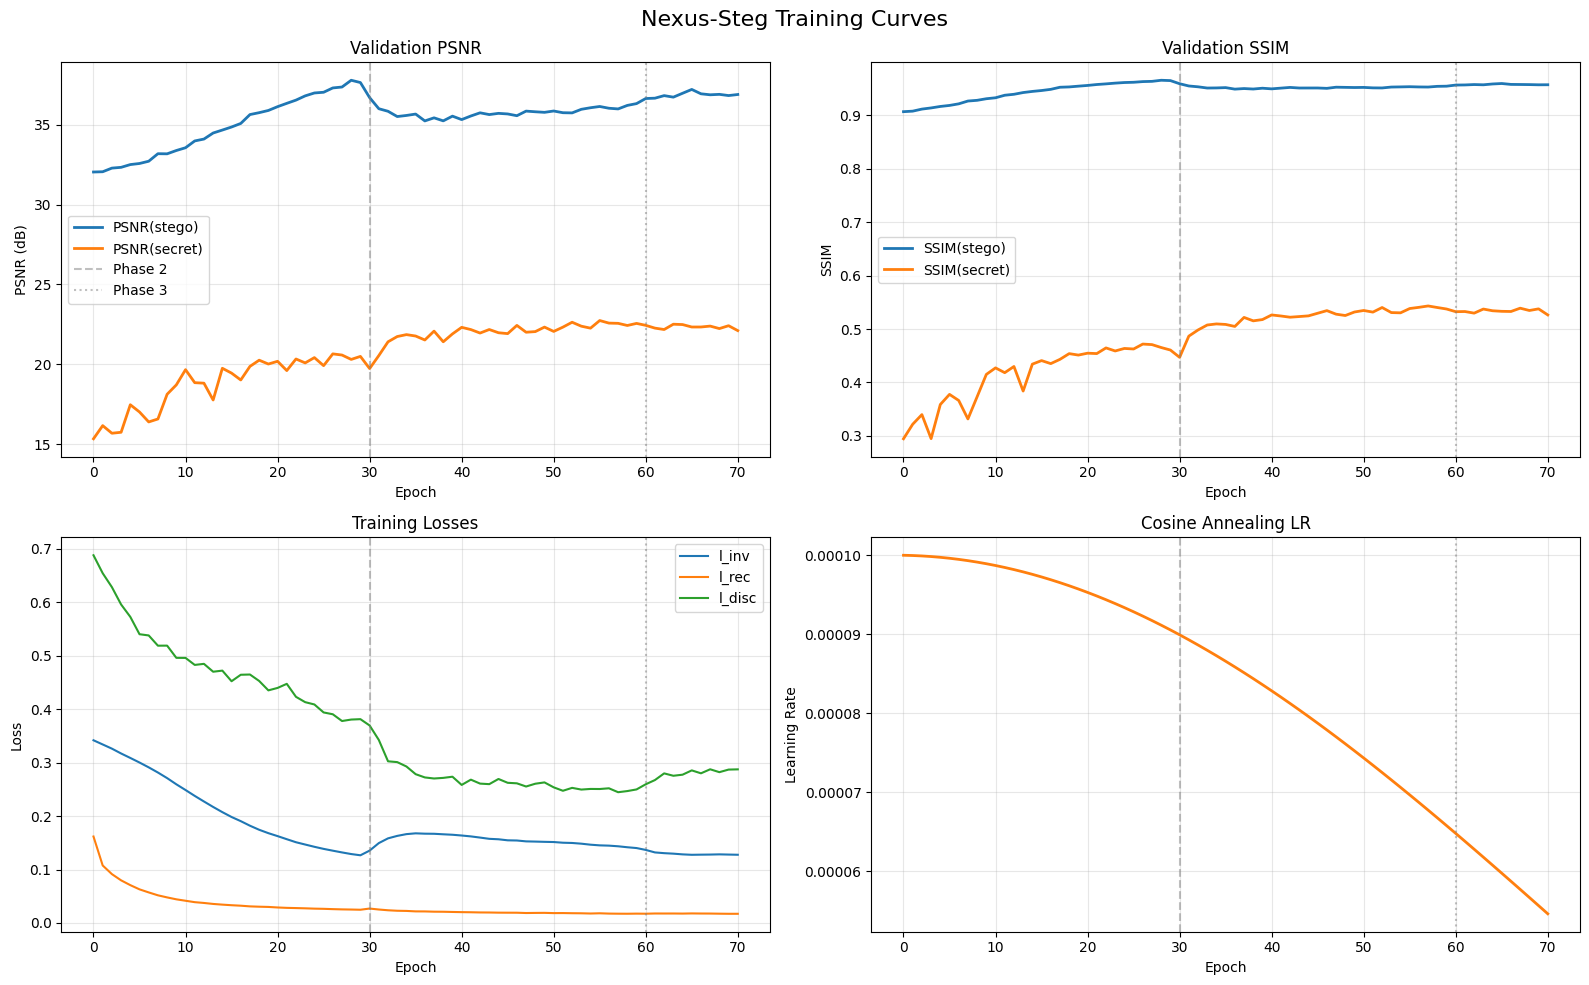

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

%cd "$PROJECT_DIR"
df = pd.read_csv("results/training_log.csv")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Nexus-Steg Training Curves", fontsize=16)

ax = axes[0, 0]
ax.plot(df["epoch"], df["val_psnr_stego"], label="PSNR(stego)", linewidth=2)
ax.plot(df["epoch"], df["val_psnr_secret"], label="PSNR(secret)", linewidth=2)
ax.axvline(x=30, color="gray", linestyle="--", alpha=0.5, label="Phase 2")
ax.axvline(x=60, color="gray", linestyle=":", alpha=0.5, label="Phase 3")
ax.set_xlabel("Epoch"); ax.set_ylabel("PSNR (dB)")
ax.set_title("Validation PSNR"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(df["epoch"], df["val_ssim_stego"], label="SSIM(stego)", linewidth=2)
ax.plot(df["epoch"], df["val_ssim_secret"], label="SSIM(secret)", linewidth=2)
ax.axvline(x=30, color="gray", linestyle="--", alpha=0.5)
ax.axvline(x=60, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Epoch"); ax.set_ylabel("SSIM")
ax.set_title("Validation SSIM"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(df["epoch"], df["l_inv"], label="l_inv", linewidth=1.5)
ax.plot(df["epoch"], df["l_rec"], label="l_rec", linewidth=1.5)
ax.plot(df["epoch"], df["l_disc"], label="l_disc", linewidth=1.5)
ax.axvline(x=30, color="gray", linestyle="--", alpha=0.5)
ax.axvline(x=60, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training Losses"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(df["epoch"], df["lr"], linewidth=2, color="tab:orange")
ax.axvline(x=30, color="gray", linestyle="--", alpha=0.5)
ax.axvline(x=60, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Epoch"); ax.set_ylabel("Learning Rate")
ax.set_title("Cosine Annealing LR"); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/training_curves.png", dpi=150)
plt.show()

## 9. Evaluate

Runs 8 attack tests: Basic Recovery, JPEG-90, JPEG-50, Blur, Noise, Screenshot, Social Media, Steganalysis.

In [ ]:
%cd "$PROJECT_DIR"
!python evaluate.py --checkpoint checkpoints/nexus_best.pth

## 10. Display Visual Results

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob, os

%cd "$PROJECT_DIR"

epoch_imgs = []
for target in [0, 29, 59, 99]:
    path = f"results/epoch_{target}.png"
    if os.path.exists(path):
        epoch_imgs.append((target, path))

if not epoch_imgs:
    all_epochs = sorted(glob.glob("results/epoch_*.png"))
    for p in all_epochs[:4]:
        e = int(os.path.basename(p).split("_")[1].split(".")[0])
        epoch_imgs.append((e, p))

if epoch_imgs:
    fig, axes = plt.subplots(len(epoch_imgs), 1, figsize=(20, 5 * len(epoch_imgs)))
    if len(epoch_imgs) == 1:
        axes = [axes]
    for ax, (e, path) in zip(axes, epoch_imgs):
        ax.imshow(mpimg.imread(path))
        ax.set_title(f"Epoch {e}  [cover | secret | stego | revealed]", fontsize=13)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No epoch images found yet.")

print("\n--- Evaluation Attack Results ---\n")
eval_imgs = sorted(glob.glob("results/evaluation/*.png"))
if eval_imgs:
    fig, axes = plt.subplots(len(eval_imgs), 1, figsize=(20, 4 * len(eval_imgs)))
    if len(eval_imgs) == 1:
        axes = [axes]
    for ax, path in zip(axes, eval_imgs):
        ax.imshow(mpimg.imread(path))
        ax.set_title(os.path.splitext(os.path.basename(path))[0].replace("_", " ").title(), fontsize=12)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No evaluation images found. Run Cell 8 first.")

Output hidden; open in https://colab.research.google.com to view.

## 11. Evaluation Report

In [ ]:
import os
%cd "$PROJECT_DIR"

report_path = "results/evaluation/report.txt"
if os.path.exists(report_path):
    with open(report_path) as f:
        print(f.read())
else:
    print("No evaluation report found. Run Cell 8 first.")

/content/Nexus-Steg
NEXUS-STEG EVALUATION REPORT

FAIL  | Basic Recovery                      | PSNR=24.54dB  SSIM=0.5456
WARN  | JPEG-90 Robustness                  | PSNR=19.54dB  SSIM=0.3917
WARN  | JPEG-50 Robustness (heavy)          | PSNR=16.87dB  SSIM=0.2784
PASS  | Gaussian Blur (sigma=2.0)           | PSNR=20.16dB  SSIM=0.4452
PASS  | Gaussian Noise (std=0.05)           | PSNR=23.90dB  SSIM=0.4935
PASS  | Screenshot Sim (resize 50%)         | PSNR=23.27dB  SSIM=0.5203
PASS  | Social Media (WhatsApp-like)        | PSNR=17.43dB  SSIM=0.3061
FAIL  | Steganalysis Detection              | PSNR=91.67dB  SSIM=0.0000

SUMMARY: 4/8 PASS | 2/8 WARN | 2/8 FAIL

